In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as p

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 3)
EPOCHS = 100


In [2]:
from keras.preprocessing.image import ImageDataGenerator

root_path = "smile/"

gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load Data
train_dataset = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes=["smile","non_smile"],
    shuffle=True,
    batch_size=32,
    target_size=(64,64),
    subset="training"
)

validation_dataset = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes=["smile","non_smile"],
    shuffle=True,
    batch_size=32,
    target_size=(64,64),
    subset="validation"
)

Found 963 images belonging to 2 classes.
Found 240 images belonging to 2 classes.


In [14]:
model = Sequential()
model.add(Conv2D(filters = 16, kernel_size = (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D())
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dense(2, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=(validation_dataset), callbacks=[es])

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 62, 62, 16)        448       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 31, 31, 16)       0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 31, 31, 16)        0         
                                                                 
 batch_normalization_5 (Batc  (None, 31, 31, 16)       64        
 hNormalization)                                                 
                                                                 
 flatten_5 (Flatten)         (None, 15376)             0         
                                                                 
 dense_8 (Dense)             (None, 512)              

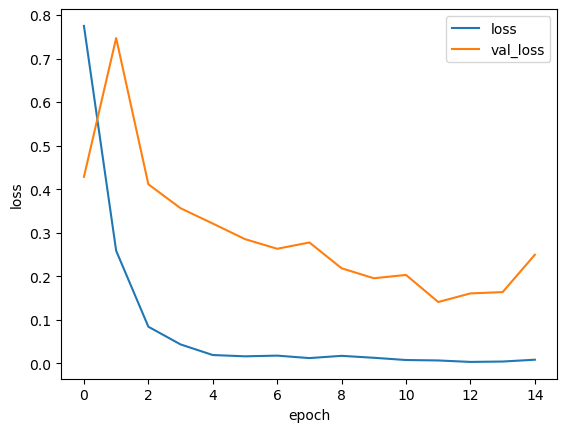

In [15]:
hist = pd.DataFrame(history.history)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

8/8 [==============================] - 0s 31ms/step


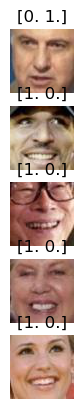

In [4]:
y_pred = model.predict(validation_dataset)
for i in range(1,6):
    img, label = validation_dataset.next()
    plt.subplot(5,1,i)
    plt.imshow(img[0])
    plt.axis('off')
    plt.title(label[0])
    

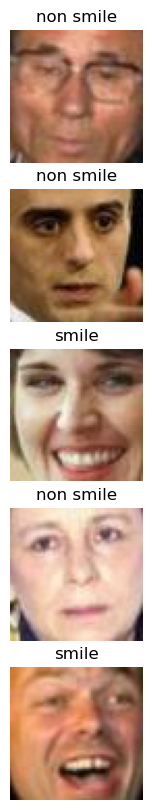

In [5]:
plt.figure(figsize=(10,10))
for i in range(1,6):
    img, label = validation_dataset.next()
    plt.subplot(5,1,i)
    plt.imshow(img[0])
    plt.axis('off')
    if label[0][0]==1:
        plt.title("smile")
    else:
        plt.title("non smile")

In [6]:
model = Sequential()
model.add(Conv2D(filters = 4, kernel_size = (3, 3), activation='relu', input_shape=(64, 64, 3))) #filters to change
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(filters = 8, kernel_size = (3, 3), activation='relu', input_shape=(64, 64, 3))) #filters to change
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu')) #add dense layer
model.add(Dense(2, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=(validation_dataset))

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 62, 62, 4)         112       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 31, 31, 4)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 29, 29, 8)         296       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 8)        0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 1568)              0         
                                                                 
 dense_1 (Dense)             (None, 64)               

InvalidArgumentError: Graph execution error:

Detected at node 'sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits' defined at (most recent call last):
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
      app.start()
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\site-packages\ipykernel\kernelapp.py", line 712, in start
      self.io_loop.start()
    File "C:\Users\marci\anaconda3\envs\zajecia\lib\site-packages\tornado\platform\asyncio.py", line 215, in